In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
 
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [23]:
master = pd.read_csv('../data/processed/county_master.csv')

In [24]:
print('Shape:', master.shape)
print('Columns:', list(master.columns))
master.head()

Shape: (47, 23)
Columns: ['County', 'Total_beds', 'Total_facilities', 'closed', 'fully-functional', 'non-functional', 'semi-functional', 'Total_health_units', 'Pct_fully_functional', 'Pct_non_functional', 'Total_pharmacies', 'Registered_pharmacies', 'Pct_pharmacies_registered', 'Public_facilities', 'Total_for_ownership', 'Public_facility_ratio', 'Facility_reported_beds', 'Suspect_zero_bed_count', 'Population', 'Beds_per_10k', 'Facilities_per_10k', 'Pharmacies_per_10k', 'Infrastructure_score']


,County,Total_beds,Total_facilities,closed,fully-functional,non-functional,semi-functional,Total_health_units,Pct_fully_functional,Pct_non_functional,...,Public_facilities,Total_for_ownership,Public_facility_ratio,Facility_reported_beds,Suspect_zero_bed_count,Population,Beds_per_10k,Facilities_per_10k,Pharmacies_per_10k,Infrastructure_score
0,baringo,820,251,0,23,23,11,57,40.4,40.4,...,0,251,0.0,820.0,9,666763,12.30,3.76,2.73,0.208
1,bomet,845,188,0,49,0,69,118,41.5,0.0,...,0,188,0.0,849.0,11,875689,9.65,2.15,1.40,0.173
2,bungoma,2038,244,0,224,2,91,317,70.7,0.6,...,0,244,0.0,2038.0,3,1670570,12.20,1.46,0.74,0.317
3,busia,1314,157,0,182,0,3,185,98.4,0.0,...,0,157,0.0,1314.0,2,893681,14.70,1.76,0.78,0.455
4,elgeyo-marakwet,858,134,0,11,32,19,62,17.7,51.6,...,0,134,0.0,858.0,15,454480,18.88,2.95,2.05,0.222


In [25]:
features = [
    'Beds_per_10k',
    'Facilities_per_10k',
    'Pharmacies_per_10k',
    'Pct_fully_functional',
    'Pct_non_functional',
    'Pct_pharmacies_registered',
    'Suspect_zero_bed_count'
]

In [26]:
target = 'Infrastructure_score'

In [27]:
X = master[features].copy()
y = master[target].copy()
counties = master['County'].copy()

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
loo = LeaveOneOut()
baseline_model = LinearRegression()

baseline_scores = cross_val_score( baseline_model, X_scaled, y,
    cv=loo,scoring='r2'
)

In [30]:
baseline_predictions = []
baseline_actuals = []

In [31]:
for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    baseline_model.fit(X_train, y_train)
    baseline_predictions.append(baseline_model.predict(X_test)[0])
    baseline_actuals.append(y_test.values[0])

 
baseline_mae  = mean_absolute_error(baseline_actuals, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actuals, baseline_predictions))
baseline_r2   = r2_score(baseline_actuals, baseline_predictions)

In [32]:
print("Linear Regression Baseline Model")
print(f'MAE:  {baseline_mae:.4f}')
print(f'RMSE: {baseline_rmse:.4f}')
print(f'R²:   {baseline_r2:.4f}')
print()

 

Linear Regression Baseline Model
MAE:  0.0003
RMSE: 0.0003
R²:   1.0000



In [33]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,        
    min_samples_leaf=3, 
    random_state=42
)

rf_predictions = []
rf_actuals = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    rf_model.fit(X_train, y_train)
    rf_predictions.append(rf_model.predict(X_test)[0])
    rf_actuals.append(y_test.values[0])
     
rf_mae  = mean_absolute_error(rf_actuals, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(rf_actuals, rf_predictions))
rf_r2   = r2_score(rf_actuals, rf_predictions)
 

print(f'MAE:  {rf_mae:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'R²:   {rf_r2:.4f}')
 

MAE:  0.0388
RMSE: 0.0510
R²:   0.8180


In [34]:
ridge_model = Ridge(alpha=1.0)
 
ridge_predictions = []
ridge_actuals = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    ridge_model.fit(X_train, y_train)
    ridge_predictions.append(ridge_model.predict(X_test)[0])
    ridge_actuals.append(y_test.values[0])
 
ridge_mae  = mean_absolute_error(ridge_actuals, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(ridge_actuals, ridge_predictions))
ridge_r2   = r2_score(ridge_actuals, ridge_predictions)
 

print(f'MAE:  {ridge_mae:.4f}')
print(f'RMSE: {ridge_rmse:.4f}')
print(f'R²:   {ridge_r2:.4f}')

MAE:  0.0028
RMSE: 0.0037
R²:   0.9991


In [35]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Ridge Regression'],
    'MAE':   [baseline_mae, rf_mae, ridge_mae],
    'RMSE':  [baseline_rmse, rf_rmse, ridge_rmse],
    'R2':    [baseline_r2, rf_r2, ridge_r2]
})
 
print()
print('Model Comparison')
print(comparison.to_string(index=False))

best_model_name = comparison.sort_values('MAE').iloc[0]['Model']
print(f'\nBest model by MAE: {best_model_name}')


Model Comparison
            Model      MAE     RMSE       R2
Linear Regression 0.000258 0.000298 0.999994
    Random Forest 0.038842 0.051050 0.817970
 Ridge Regression 0.002788 0.003680 0.999054

Best model by MAE: Linear Regression


In [36]:
rf_model.fit(X_scaled, y)

RandomForestRegressor(max_depth=3, min_samples_leaf=3, n_estimators=200,
                      random_state=42)

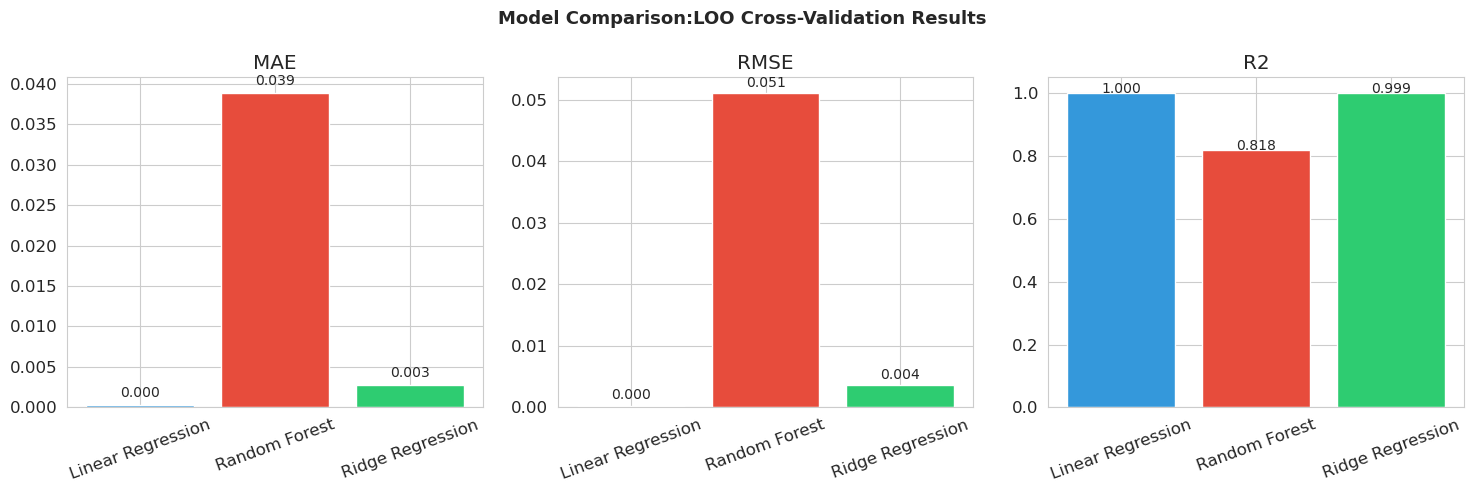

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#3498db', '#e74c3c', '#2ecc71']
 
for i, metric in enumerate(metrics):
    axes[i].bar(comparison['Model'], comparison[metric], color=colors, edgecolor='white')
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=20)
    for j, val in enumerate(comparison[metric]):
        axes[i].text(j, val + 0.001, f'{val:.3f}', ha='center', fontsize=10)
 
plt.suptitle('Model Comparison:LOO Cross-Validation Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

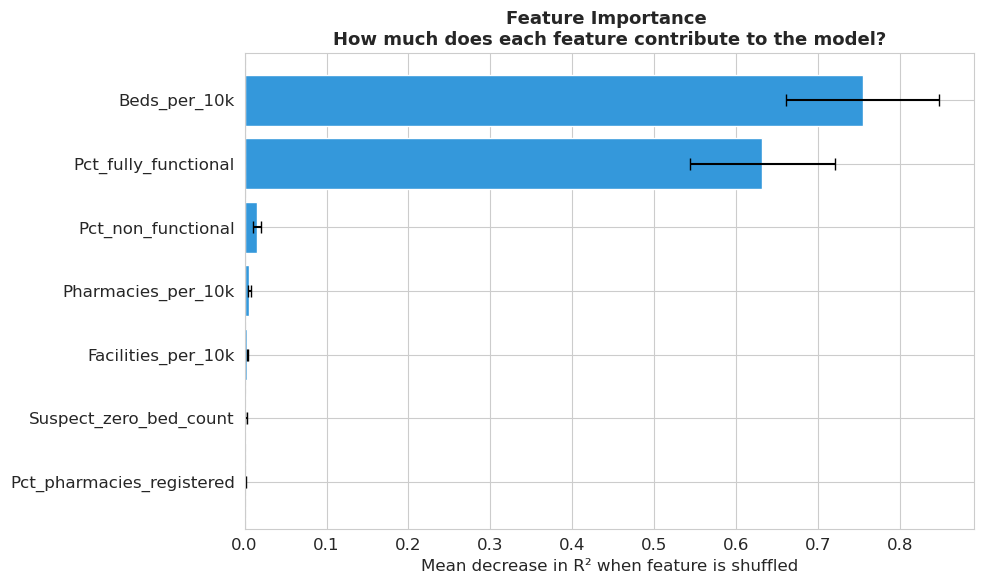

Feature importance ranking:
                  Feature  Importance
             Beds_per_10k    0.754688
     Pct_fully_functional    0.631997
       Pct_non_functional    0.015459
       Pharmacies_per_10k    0.005854
       Facilities_per_10k    0.003350
   Suspect_zero_bed_count    0.002194
Pct_pharmacies_registered    0.000985


In [38]:
perm_importance = permutation_importance(rf_model, X_scaled, y,
    n_repeats=30,random_state=42)

importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': perm_importance.importances_mean,
    'Std':        perm_importance.importances_std
}).sort_values('Importance', ascending=True)
 
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    xerr=importance_df['Std'],
    color='#3498db',
    edgecolor='white',
    capsize=4
)
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
plt.title('Feature Importance \nHow much does each feature contribute to the model?',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean decrease in R² when feature is shuffled')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()
 
print('Feature importance ranking:')
print(importance_df.sort_values('Importance', ascending=False)[['Feature', 'Importance']].to_string(index=False))
 

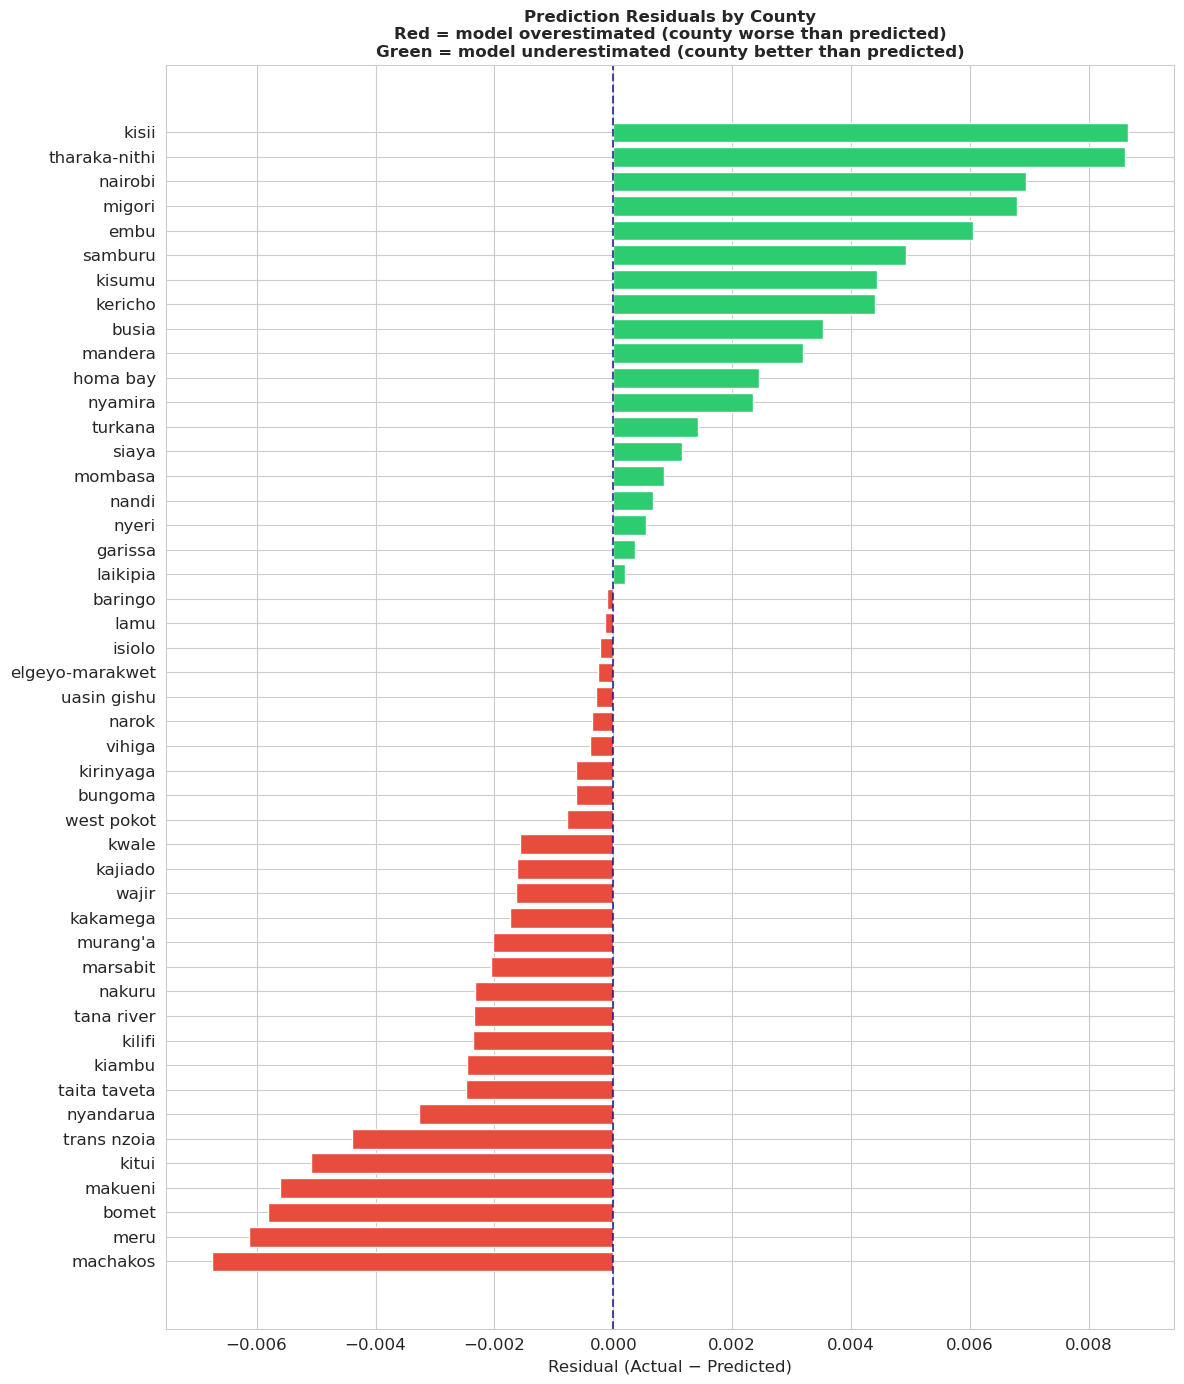

Counties the model overestimated the most (predicted better than reality):
  County  Actual  Predicted  Residual
machakos   0.196   0.202758 -0.006758
    meru   0.249   0.255126 -0.006126
   bomet   0.173   0.178815 -0.005815
 makueni   0.208   0.213613 -0.005613
   kitui   0.219   0.224093 -0.005093

Counties the model underestimated the most (reality is better than predicted):
       County  Actual  Predicted  Residual
        kisii   0.537   0.528341  0.008659
tharaka-nithi   0.603   0.594386  0.008614
      nairobi   0.490   0.483067  0.006933
       migori   0.555   0.548204  0.006796
         embu   0.568   0.561950  0.006050


In [39]:
residuals_df = pd.DataFrame({
    'County':    counties.values,
    'Actual':    ridge_actuals,
    'Predicted': ridge_predictions,
    'Residual':  [a - p for a, p in zip(ridge_actuals, ridge_predictions)]
})
 
residuals_df['Direction'] = residuals_df['Residual'].apply(
    lambda x: 'Underestimated' if x > 0 else 'Overestimated'
)

residuals_df = residuals_df.sort_values('Residual')
colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in residuals_df['Residual']]
plt.figure(figsize=(12, 14))
plt.barh(residuals_df['County'], residuals_df['Residual'],
         color=colors, edgecolor='white')
plt.axvline(x=0, color='navy', linestyle='--', alpha=0.7)
plt.title('Prediction Residuals by County\n'
          'Red = model overestimated (county worse than predicted)\n'
          'Green = model underestimated (county better than predicted)',
          fontsize=12, fontweight='bold')
plt.xlabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig('../outputs/figures/residuals_by_county.png', dpi=150)
plt.show()
 
print('Counties the model overestimated the most (predicted better than reality):')
print(residuals_df[residuals_df['Residual'] < 0]
      .sort_values('Residual')[['County', 'Actual', 'Predicted', 'Residual']]
      .head(5)
      .to_string(index=False))
 
print()
print('Counties the model underestimated the most (reality is better than predicted):')
print(residuals_df[residuals_df['Residual'] > 0]
      .sort_values('Residual', ascending=False)[['County', 'Actual', 'Predicted', 'Residual']]
      .head(5)
      .to_string(index=False))
 

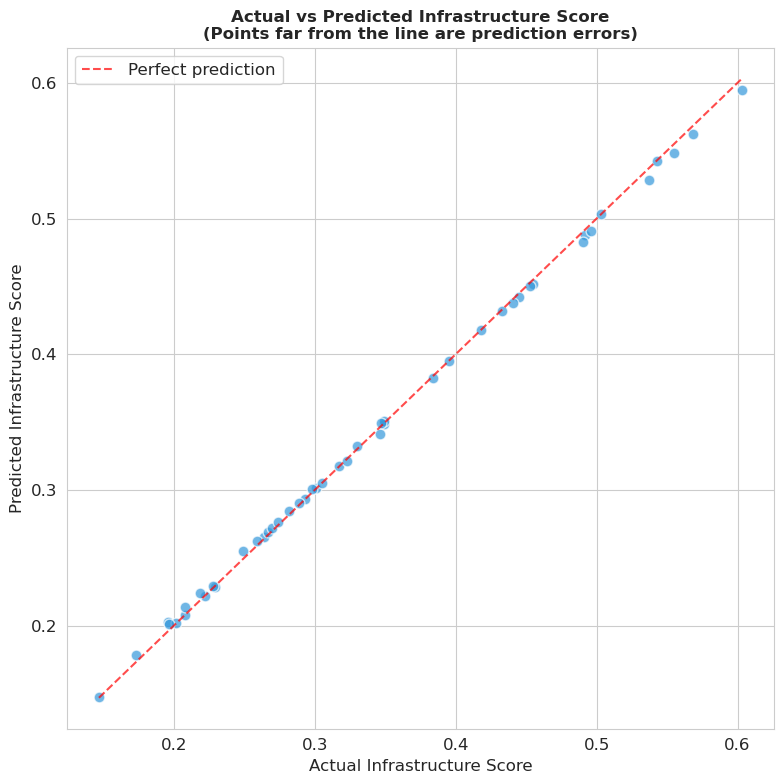

In [40]:

plt.figure(figsize=(8, 8))
plt.scatter(
    ridge_actuals, ridge_predictions,
    color='#3498db', alpha=0.7, s=60, edgecolors='white'
)
 

min_val = min(min(ridge_actuals), min(ridge_predictions))
max_val = max(max(ridge_actuals), max(ridge_predictions))
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', alpha=0.7, label='Perfect prediction')
 

for _, row in residuals_df[abs(residuals_df['Residual']) > 0.08].iterrows():
    plt.annotate(
        row['County'].title(),
        (row['Actual'], row['Predicted']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )
 
plt.xlabel('Actual Infrastructure Score')
plt.ylabel('Predicted Infrastructure Score')
plt.title('Actual vs Predicted Infrastructure Score\n(Points far from the line are prediction errors)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted.png', dpi=150)
plt.show()
 

In [41]:

results = master[['County', 'Population', 'Infrastructure_score']].copy()
results = results.merge(
    residuals_df[['County', 'Predicted', 'Residual', 'Direction']],
    on='County'
)
results.to_csv('../data/processed/model_results.csv', index=False)
 
print('Saved:')
print('  data/processed/model_residuals.csv')
print('  data/processed/model_results.csv')

Saved:
  data/processed/model_residuals.csv
  data/processed/model_results.csv


In [42]:


os.makedirs('../streamlit_app/models', exist_ok=True)

joblib.dump(ridge_model, '../streamlit_app/models/ridge_model.pkl')
joblib.dump(scaler, '../streamlit_app/models/scaler.pkl')
joblib.dump(rf_model, '../streamlit_app/models/rf_model.pkl')

['../streamlit_app/models/rf_model.pkl']